# CS 503 Foundation Models: Part 2 - nanoMaskGIT

#### Goals:

The goal of this second part is to familiarize yourself with the following topics:
- Bi-directional attention
- Encoder-only Transformer (e.g. BERT, MaskGIT, ...) models
- Basic masking schemes
- Masked modelling on text and images
- Masked inference

This notebook should give you a solid foundation of working with masked image models.
If you want to know more about these topics, please see some of the reading material in the lectures and at the bottom of this notebook, and feel free to ask the TAs.


#### Instructions:

- Your task is to fill in the missing code in the acompagning codebase (highlighted by `???`), run the training loops and evaluate the trained models with this notebook.
- Submit the notebook with all cells executed, as well as `nanofm/models/maskgit.py`.
- The notebooks are individual homework.

# 1. Setup

Please follow the instructions in the [README.md](../README.md) file to set up the environment.

### 1.1 Imports

In [1]:
# Switch path to root of project
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
current_folder = globals()['_dh'][0]
os.chdir(os.path.dirname(os.path.abspath(current_folder)))

%load_ext autoreload
%autoreload 2

In [2]:
import re
import torch
from einops import rearrange
from transformers import AutoTokenizer
from tokenizers.processors import TemplateProcessing

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

from nanofm.utils.checkpoint import load_model_from_safetensors
from nanofm.data.vision.tokenized_mnist import create_tokenized_mnist_dataloader, detokenize_MNIST

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# The flag below controls whether to allow TF32 on matmul. This flag defaults to False in PyTorch 1.12 and later.
torch.backends.cuda.matmul.allow_tf32 = True
# The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
torch.backends.cudnn.allow_tf32 = True

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_grad_enabled(False)

/home/garate/miniconda3/envs/nanofm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.autograd.grad_mode.set_grad_enabled(mode=False)

---

## 2 Training nanoMaskGIT on MNIST for image generation

In this exercise, we will implement a simplified masked generative model, similar to [MaskGIT](https://masked-generative-image-transformer.github.io/). 
As with our nanoGPT implementation, we will train it on MNIST for image generation, but will also later explore using it for text generation on TinyStories!

#### Masked modeling - Training objective

In contrast to autoregressive models that are trained to predict the next token given the context so far, masked generative models like MaskGIT are trained to predict any (masked-out) token given any other (non-masked) subset of tokens.
Consider the following example: 

**Original Sentence:**  
```
"The quick brown fox jumps over the lazy dog."
```

**Masked Training Example (cloze):**  
```
"The quick [MASK] fox jumps over the [MASK] dog."
```

**Goal:**  
The model must predict:
- `[MASK]` → "brown"
- `[MASK]` → "lazy"

By repeatedly training the model to predict these randomly masked tokens across a large dataset, MaskGIT learns how tokens fit contextually within sequences.


#### Masked modeling - Inference


By training a model with randomized masking ratios, we are able to use it to progressively "unmask" a fully masked initial sequence.
At inference, the model starts with all tokens masked and progressively unmasks tokens in multiple steps. Let's show an inference example generating two (`k=2`) tokens at a time.

**Initial Masked Sequence:**  
```
"[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]"
```

**Step-by-step Generation (k=2 tokens at a time):**  

- **Step 1:**  
```
"The [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] dog."
```

- **Step 2:** (unmask next 2 most confident tokens)  
```
"The quick [MASK] [MASK] [MASK] [MASK] [MASK] lazy dog."
```

- **Step 3:** (unmask next 2 tokens)  
```
"The quick [MASK] fox [MASK] [MASK] [MASK] lazy dog."
```

- **Step 4:** (unmask next 2 tokens)  
```
"The quick brown fox jumps [MASK] the lazy dog."
```

- **Step 5 (Final):** (all tokens unmasked)  
```
"The quick brown fox jumps over the lazy dog."
```

At each inference step, MaskGIT predicts all masked-out tokens simultaneously (in parallel), and, based on the predicted probabilites, selects the `k` (here `k=2`) most likely tokens. 
After deciding on which tokens to use, we sample a token index from the predicted probability distribution for each token, and add the tokens to the sequence. 
This, now slightly less masked, sequence is then used as the input for the next round, where again, the `k=2` most confident tokens are chosen of the remaining masked targets.

A crucial difference of masked models to next-token prediction is that at each inference step we can freely choose the number of tokens `k` to simultaneously decode. 
Depending on the choice of `k`, this can speed up inference significantly, at little cost to generation performance. 
For example, see the comparison between raster-scan autoregressive, and masked generation below.
Each frame of the gif is one generation step. Autoregressive generation predicts each token one-by-one, while masked models may predict them in parallel.

![adsf](https://masked-generative-image-transformer.github.io/imgs/sampling.gif)

### 2.1 Overview and tasks

To implement nanoMaskGIT, we ask you to complete the subsections below by directly filling in the missing lines in the code base.

#### 2.1.1 Initialize nanoMaskGIT (5 points)

We will reuse the exact same Transformer layers and trunk built last week for the nanoGPT model, but this time we will use it to assemble a MaskGIT-like model in `nanofm.models.maskgit.MaskGIT`.
It consists of a few operations executed in series. Initialize the following modules in the constructor:
1. The discrete input tokens are embedded with an `nn.Embedding` layer. Initialize `self.input_embedding` accordingly, taking into account the vocabulary size.
2. On top of that, we add learnable positional embeddings. Initialize `self.positional_embedding` as an `nn.Parameter` containing a randomly initialized Tensor of shape (`max_seq_len`, `dim`).
3. To indicate masked-out tokens and provide placeholders to write the targets, initialize `self.mask_token` as an `nn.Parameter` containing a randomly initialized Tensor of shape (`dim`).
4. This then gets passed to a Transformer trunk. Initialize `self.trunk` with the trunk you implemented last week.
5. Finally we project the trunk output through a LayerNorm and output projection that maps the elements from the Transformer dimension to the vocabulary size (as a one-hot vector per token). Initialize `self.out_norm` and `self.to_logits`. The bias term for `self.to_logits` should always be set to False.

#### 2.1.2 Implement the forward function and loss (10 points)

Next, let's implement the `forward_model` function:
1. Pass the input tokens through the embedding. 
2. Given the `mask`, replace these embeddings by the learned `self.mask_token`, wherever `mask == True`.
3. Add the positional embedding, pass it through the Transformer trunk, output normalization, and output projection.
4. When calling the Transformer trunk, no attention mask needs to be specified. This model performs full self-attention between all masked and non-masked tokens.

Finally, we need to compute the cross-entropy loss between the logits and the ground-truth targets. Please complete the `compute_ce_loss` function accordingly, and take into account the ignore_index token. We do not want to compute a loss on non-masked tokens that we pass as input; we only compute it on masked-out tokens that we predict.

#### 2.1.3 Implement random masking (15 points)

As used in the `forward` function, during training we want to randomize the `mask` you just applied to the inputs. 
For that, please complete the `generate_random_mask` function that should return a random mask where True = masked-out and False = not masked.
Each sample in the batch should randomly mask out between 1 and L tokens, where L is the sequence length. 
When L tokens are masked-out, it means there is no input and all tokens are predicted.
When only 1 token is masked-out, it means that all but one token are given as input, and only one is predicted. 
You should be able to see why we have to have at least one token masked.

The returned mask tensor should be of type `torch.BoolTensor`, moved to the same device (GPU) as `seq`, and be of shape (B, L).
Note that both the number of mask tokens, as well as the placement of the masks should be sampled completely uniformly at random, for every sample in the batch individually.
That means you should not apply and broadcast the same mask to the entire batch.

#### 2.1.4 MaskGIT schedule and generation function (20 points)

Now let's implement the generation function. We do that in two steps:

First, let's implement a so-called generation schedule in `get_maskgit_schedule`. 
Its task is to give us a list of number of tokens to unmask at every prediction step. 
It's quite common to make this a cosine schedule, i.e. where the tokens are unmasked slowly at the beginning, then in the middle many tokens are predicted at once, and finally in the end we ramp down again.
Here we will implement a much simpler constant schedule, where the number of unmasked tokens per step is constant.
For example, if total_tokens = 17 and num_steps = 8, then the schedule should be: [2, 2, 2, 2, 2, 2, 2, 3]. 
If the total number of tokens is not divisible by the number of steps, we simply add the remainder to the last step.
The `schedule` should be a list of integers of length `num_steps`, where each integer represents the number of tokens to unmask at that step. 
The sum of the integers in `schedule` should equal `total_tokens`.

With the simple schedule implemented, let's use it in the `generate` function. Generation is performed in a loop in the following steps:
1. Given the sequence and mask so far, simply pass them through the network to get the logits.
2. Then, select the subset of logits that we actually want to predict, i.e. the masked-out tokens.
3. Over all these predicted tokens, we only want to keep the most "confident" predictions. We select for these by computing the maximum logit value for each token as a proxy. The higher the maximum logit is for a given token, the more "confident" it is in its prediction.
4. Now, let's select the top-k tokens according to these confidence scores. You get the number of tokens `k` from the generation schedule.
5. Sample the token indices from these `k` selected token logits. You should use the `sample_tokens` function from `utils/sampling.py`, and remember to pass the relevant sampling hyperparameters.
6. Update the sequence and mask for the next round using the newly sampled tokens and their positions.
7. Repeat until the end of the generation schedule, when the sequence is fully unmasked.

### 2.2 Training the model

We defined a training config for you in: `cfgs/nanoMaskGIT/mnist_d8w512.yaml`. Please familiarize yourself with all parts.
Please don't forget to replace the Weights & Bias entity with your own.

On a 1xV100 node, you can start the training like:
```
OMP_NUM_THREADS=1 torchrun --nproc_per_node=1 run_training.py --config cfgs/nanoMaskGIT/mnist_d8w512.yaml
```

This training should be pretty fast and only take a few minutes. Because masked image models are harder to overfit, we increased the number of training steps five-fold, compared to nanoGPT. You should reach a final validation loss below 0.57, and your loss curves should look something like the following:

<img src="./assets/nanoMaskGIT_mnist.png" alt="nanoMaskGIT MNIST loss curves" width="1000">

### 2.3 Show your loss curves (10 points)

Screenshot your loss curves and show them here. Add the image to the `assets` directory and change the path in the markdown. You will get 10 points for reasonable loss curves (similar to the sample loss curves above).

<img src="./assets/mnistscreen1_hw_part2.png" alt="nanoMaskGIT MNIST loss curves" width="1000">

### 2.4 Evaluating the model (10 points)

After you completed the training, load the model with the following cell. You may need to adjust the path if you changed it.
You will get 10 points if the outputs look reasonable (similar to the sample outputs provided below).

Hint: You can also load intermediate safetensors checkpoints to check the progress during training.

In [3]:
ckpt_path = './outputs/nanoMaskGIT/mnist_d8w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

25.186816M parameters


Let's plot some class-conditional generations! We seed the generation by providing the first token, whose index is equal to the number we'd like to generate.
For that token, we initialize the mask with `False`, i.e. indicating that that token is given as input, i.e. not masked. 
The rest of the tokens are masked, and it does not matter what value they have in the `seq` tensor, as they are overwritten by the learnable mask token in the Transformer.

In [4]:
label = 5

seq = torch.zeros(50, dtype=torch.long, device=device)
mask = torch.ones(50, dtype=torch.bool, device=device)
seq[0] = label
mask[0] = False

output = model.generate(seq, mask, num_steps=8, temp=1.0, top_p=0.9, return_history=False)
output

tensor([[ 5, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 13, 12, 10, 10, 10, 17,
         17, 22, 18, 10, 10, 10, 25, 21, 10, 10, 10, 10, 10, 10, 14, 12, 10, 10,
         10, 10, 13, 25, 18, 10, 10, 10, 10, 10, 10, 10, 10, 10]],
       device='cuda:0')

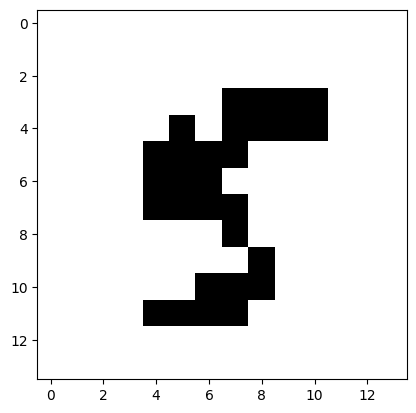

In [5]:
reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
plt.imshow(reconst[0], cmap='gray_r')

Let's now generate 10 random samples for all 10 classes. Most should look quite reasonable.

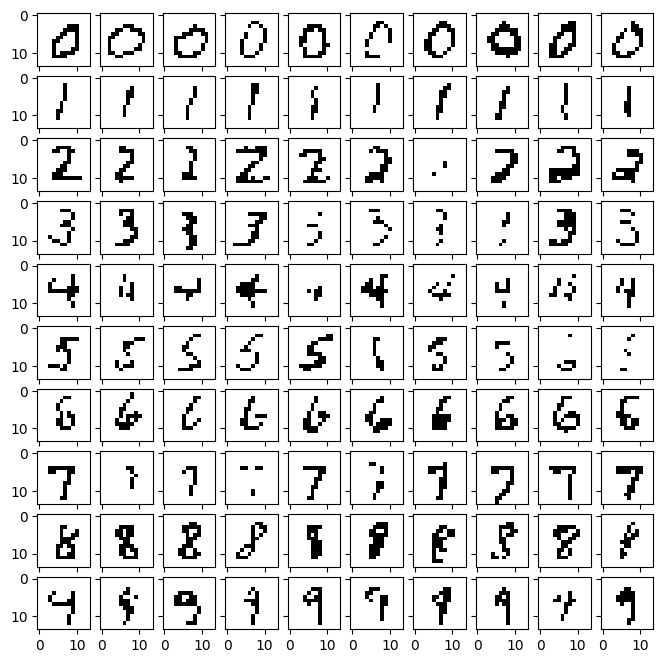

In [6]:
def generate_samples(model, num_steps=8, temp=1.0, top_p=0.0, top_k=0.0, n_samples=10):
    fig = plt.figure(figsize=(8., 8.))
    grid = ImageGrid(fig, 111, nrows_ncols=(10, n_samples), axes_pad=0.1)
    for label in range(10):
        for sample_idx in range(n_samples):
            grid_idx = label * n_samples + sample_idx
            
            seq = torch.zeros(50, dtype=torch.long, device=device)
            mask = torch.ones(50, dtype=torch.bool, device=device)
            seq[0] = label
            mask[0] = False
            output = model.generate(seq, mask, num_steps=num_steps, temp=temp, top_p=top_p, top_k=top_k, return_history=False)
            
            reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
            grid[grid_idx].imshow(reconst[0], cmap='Greys', vmin=0, vmax=1)
    plt.show()
    
generate_samples(model, num_steps=8, temp=0.7, top_p=0.9, top_k=0.0)

### 2.5 Open-ended questions (10 points each)

Please answer the following questions. You may use additional cells to demonstrate your answers if necessary.

#### 2.5.1 Intermediate generation steps

`model.generate` has an optional flag `return_history`. Show the intermediate generation steps. What do you observe?

### Answer:
First return_history: Whether to return the history of generated sequences and masks.

The history looks like: 

(tensor([[ 5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
           0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
           0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
         [ 5, 10, 10,  0,  0,  0,  0, 10, 10,  0,  0,  0,  0,  0,  0,  0,  0,  0,
           0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
           0,  0,  0,  0,  0,  0,  0, 10,  0,  0,  0,  0,  0, 10],
         [ 5, 10, 10, 10,  0,  0, 10, 10, 10,  0,  0,  0,  0,  0,  0, 10,  0,  0,
           0,  0,  0,  0, 10,  0,  0,  0,  0,  0,  0, 10,  0,  0,  0,  0,  0,  0,
          10,  0,  0,  0,  0,  0,  0, 10,  0,  0,  0,  0,  0, 10],
         [ 5, 10, 10, 10, 10, 10, 10, 10, 10,  0,  0,  0,  0,  0,  0, 10,  0,  0,
           0,  0,  0,  0, 10,  0,  0,  0,  0,  0, 10, 10,  0,  0,  0,  0,  0,  0,
          10,  0,  0,  0,  0,  0, 10, 10, 10,  0,  0,  0, 10, 10],
         [ 5, 10, 10, 10, 10, 10, 10, 10, 10, 10,  0,  0,  0,  0, 12, 10,  0,  0,
           0,  0,  0, 10, 10,  0,  0,  0,  0,  0, 10, 10,  0,  0,  0,  0,  0, 10,
          10,  0,  0,  0,  0,  0, 10, 10, 10, 10,  0, 10, 10, 10],
         [ 5, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,  0,  0,  0, 12, 10, 10,  0,
           0,  0,  0, 10, 10, 10,  0,  0,  0, 10, 10, 10,  0,  0,  0,  0,  0, 10,
          10,  0,  0,  0,  0, 10, 10, 10, 10, 10, 10, 10, 10, 10],
         [ 5, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,  0, 13, 12, 10, 10,  0,
           0,  0, 18, 10, 10, 10,  0,  0,  0, 10, 10, 10, 10,  0,  0,  0, 10, 10,
          10, 14,  0,  0,  0, 10, 10, 10, 10, 10, 10, 10, 10, 10],
         [ 5, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 13, 12, 10, 10, 10,
           0, 24, 18, 10, 10, 10,  0,  0, 10, 10, 10, 10, 10,  0,  0,  0, 10, 10,
          10, 14, 25,  0, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
         [ 5, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 13, 12, 10, 10, 10,
          11, 24, 18, 10, 10, 10, 15, 25, 10, 10, 10, 10, 10, 10, 17, 10, 10, 10,
          10, 14, 25, 18, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10]]),
 tensor([[False,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
         [False, False, False,  True,  True,  True,  True, False, False,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True, False,  True,  True,  True,  True,  True, False],
         [False, False, False, False,  True,  True, False, False, False,  True,
           True,  True,  True,  True,  True, False,  True,  True,  True,  True,
           True,  True, False,  True,  True,  True,  True,  True,  True, False,
           True,  True,  True,  True,  True,  True, False,  True,  True,  True,
           True,  True,  True, False,  True,  True,  True,  True,  True, False],
         [False, False, False, False, False, False, False, False, False,  True,
           True,  True,  True,  True,  True, False,  True,  True,  True,  True,
           True,  True, False,  True,  True,  True,  True,  True, False, False,
           True,  True,  True,  True,  True,  True, False,  True,  True,  True,
           True,  True, False, False, False,  True,  True,  True, False, False],
         [False, False, False, False, False, False, False, False, False, False,
           True,  True,  True,  True, False, False,  True,  True,  True,  True,
           True, False, False,  True,  True,  True,  True,  True, False, False,
           True,  True,  True,  True,  True, False, False,  True,  True,  True,
           True,  True, False, False, False, False,  True, False, False, False],
         [False, False, False, False, False, False, False, False, False, False,
          False,  True,  True,  True, False, False, False,  True,  True,  True,
           True, False, False, False,  True,  True,  True, False, False, False,
           True,  True,  True,  True,  True, False, False,  True,  True,  True,
           True, False, False, False, False, False, False, False, False, False],
         [False, False, False, False, False, False, False, False, False, False,
          False, False,  True, False, False, False, False,  True,  True,  True,
          False, False, False, False,  True,  True,  True, False, False, False,
          False,  True,  True,  True, False, False, False, False,  True,  True,
           True, False, False, False, False, False, False, False, False, False],
         [False, False, False, False, False, False, False, False, False, False,
          False, False, False, False, False, False, False, False,  True, False,
          False, False, False, False,  True,  True, False, False, False, False,
          False,  True,  True,  True, False, False, False, False, False,  True,
          False, False, False, False, False, False, False, False, False, False],
         [False, False, False, False, False, False, False, False, False, False,
          False, False, False, False, False, False, False, False, False, False,
          False, False, False, False, False, False, False, False, False, False,
          False, False, False, False, False, False, False, False, False, False,
          False, False, False, False, False, False, False, False, False, False]]))

where the first tensor represents the sequence and the other tensor the mask.
We see that the first element of the first tensor of sequence is just 5. At the same position (the first False) of the second tensor, the token was not masked. At each step, we unmask progressively until we have a tensor full sequence and the no mask.

In [7]:
# Fill your answer here
 

#### 2.5.2 Number of inference steps

With MaskGIT, we can freely choose the number of inference steps `k`. We default to `k=8`, but how does generation with `k` = 1, 4, 8, 16, 32, 49 perform? What do you observe?

In [8]:
# Fill your answer here
 


### Answer:
The num_steps parameter controls how many tokens are revealed at each decoding step, so intuitively 
if num_step is 1. The model reveals all tokens at once without any iterative refinement.

<img src="./assets/step1.png" alt="nanoMaskGIT MNIST loss curves" width="250">

As we can see for the number 4 or 5.

Now by increasing num_step, we will have more contexte and the model will be more accurate (num_steps=8):

<img src="./assets/step8.png" alt="nanoMaskGIT MNIST loss curves" width="250">

And finally for num_steps = 49: 

<img src="./assets/step49.png" alt="nanoMaskGIT MNIST loss curves" width="250">

Where the model struggle with the number 4 at num_step=1 now is able to have a good prediction at num_step = 49.

---

## 3 Training nanoGPT on TinyStories

Masked generation is quite common for image generation, but has seen a recent resurgence for language models too (e.g. see [LLaDA](https://ml-gsai.github.io/LLaDA-demo/)). 
Let's run a little experiment and train a masked model on TinyStories, just as we did with nanoGPT.

### 3.1 Loading the tokenizer and helper functions

In [9]:
# Load the GPT-2 tokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2", trust_remote_code=True)

# Add padding, start-of-sequence, and end-of-sequence tokens
tokenizer.add_special_tokens({'pad_token': '[PAD]'})
tokenizer.add_special_tokens({
    'bos_token': '[SOS]',
    'eos_token': '[EOS]',
})
tokenizer._tokenizer.post_processor = TemplateProcessing(
    single="[SOS] $A [EOS]",
    special_tokens=[('[EOS]', tokenizer.eos_token_id), ('[SOS]', tokenizer.bos_token_id)],
)
tokenizer

GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[SOS]', 'eos_token': '[EOS]', 'unk_token': '<|endoftext|>', 'pad_token': '[PAD]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50257: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50258: AddedToken("[SOS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50259: AddedToken("[EOS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [10]:
def token_ids_to_text(token_ids, text_tokenizer):
    """ Helper function to turn token sequences back to well-formatted text. """
    decoded = text_tokenizer.decode(token_ids)
    # Remove [SOS], [EOS], and [PAD] tokens along with surrounding horizontal whitespace only.
    decoded = re.sub(r'[ \t]*\[(SOS|EOS|PAD)\][ \t]*', ' ', decoded)
    # Collapse extra horizontal spaces in each line without touching newline characters.
    decoded = '\n'.join([re.sub(r'[ \t]+', ' ', line).strip() for line in decoded.splitlines()])
    return decoded

### 3.2 Training the model

We defined a training config for you in: `cfgs/nanoMaskGIT/tinystories_d8w512.yaml`. Please familiarize yourself with all parts.
Please don't forget to replace the Weights & Bias entity with your own.

On a 2xV100 node, you can start the training like:
```
OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 run_training.py --config cfgs/nanoMaskGIT/tinystories_d8w512.yaml
```

This training should take over one hour. You should reach a final validation loss around 2.05, and your loss curves should look something like the following:

<img src="./assets/nanoMaskGIT_tinystories.png" alt="nanoMaskGIT TinyStories loss curves" width="1000">

### 3.3 Show your loss curves (10 points)

Screenshot your loss curves and show them here. Add the image to the `assets` directory and change the path in the markdown. You will get 10 points for reasonable loss curves (similar to the sample loss curves above).

[Note] Your screenshot must clearly show your Weights & Biases (W&B) account (username/entity), usually visible in the top-right corner of the page.

<img src="./assets/tinystor_hw_part2.png" alt="nanoMaskGIT TinyStories loss curves" width="1000">

### 3.4 Evaluating the model (10 points)

After you completed the training, load the model with the following cell. You may need to adjust the path if you changed it.
You will get 10 points if the outputs look reasonable (similar to the sample outputs provided below).

Hint: You can also load intermediate safetensors checkpoints to check the progress during training.

In [11]:
ckpt_path = './outputs/nanoMaskGIT/tinystories_d8w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

25.186816M parameters


Let's generate some random (unconditional) stories!

In [20]:
for _ in range(5):
    seq = torch.zeros(256, dtype=torch.long, device=device)
    mask = torch.ones(256, dtype=torch.bool, device=device)
    output = model.generate(seq, mask, num_steps=128, temp=1.0, top_k=100, return_history=False)
    print(token_ids_to_text(output[0], text_tokenizer=tokenizer))
    print('\n' + '-'*50 + '\n')

Tom upon a time, there was an old man, Tom. Tom loved to find new places and every day. He often packed his bag with his and went to the nearby island.

"Tom, don't you have to leave on your island today

Tom didn't mind. He stayed close was an oyster and smiled at it. "Ah never what it looks like an unfamiliar color, Mom," he said sadly.

"It looks like old, but Tom replied his Mom

Tom nodded and head. Suddenly, heard a voice. from his of the lake heard

"Tom you have said there?"

Tom followed the voice and a kind old

HisHe was to talk for a."

He walked up. Then man said, "�€œOk! I'm going to take a swim." the old said with

Tom took a deep breath and was able to follow the man. He soon through the water, and soon he realized that was just a lot of exciting places to explore, and see an unknown island.

He was so excited to tell her about his adventure to his adventures. He couldn't wait to come back to their island.

--------------------------------------------------

Once upon a

### 3.5 Open-ended questions (10 points each)

Please answer the following questions. You may use additional cells to demonstrate your answers if necessary.

#### 3.5.1 Intermediate generation steps

Similar as in 2.5.1, `model.generate` has an optional flag `return_history`. Show the intermediate generation steps. What do you observe?

In [ ]:
# # Fill your answer here
# L upon a time, was a boy named Timmy. He loved to play with his friends, Lily. One day, Timmy was with the ball when Lily accidentally to him her. She Timmy started to want to take because he realized what should say, he she said no. Timmy felt sad, but he thought friends wanted right. He decided to settle the bench while she little while and have a.
# he sat down, where Lily saw Timmy's toy. Shemy had't being very selfish and Lily sharing and having fun. Timmy realized that he was rude by being kind and understanding.

# Lily realized that sharing was better good to share and to others happy. She decided to be more rude than to others. They said together and played with his friend in the end. Timmy learned that it's better always play with selfish and are kind and be mean to those who lost it.

# --------------------------------------------------

# Once upon a time, there was a little girl named Lily. She loved to play outside and pick flowers. One day, she was too careless for her mom's words. She asked her why she couldn't hear a word "Because"No sweetie" it's only a word one you,".


# " mom started, herLily, can don't understand about word. You can always ask attention should who you want to learn."

# Lily thought about what her mom said said and was told good.. She knew Mom was right. From learned, she should asking questions, and asked for mom to help her She knew it, important to follow the for something, but she understood proud of what she said.

# Lily learned that it's always important to ask for words without asking for more words when she was all by what friends

# --------------------------------------------------

# Once upon a time, there was a little girl named Lily. She lived in a small house with her mommy and daddy. One day, Lily's her daddymy asked the baby to feed a bird. Lily got scared know what about vet birds or," her mommy and daddy told her a question to her another question.

# Lily was very curious of what because they was watching. She asked what mommy and daddy what were thinking was going to. The whispered to, "�€œWe have Lily so feed the." Lily
# LaterAs they looked,, Lily heard a baby bird sing a loudly as. She asked her mommy and daddy, "Oh no we saw?" Her mommy said, "It, they bird is singing and singing together they were listening and listening to the birds. Soon, the bird flew away. Lily was so happy that she couldn could wait to feed the baby birds with baby bird.

# --------------------------------------------------

# Once upon a time, there was a little bird named Birdety. Tweety lived in a big nest with many nest of birds in it trunk. One day, the bird tried to stretch on the branch of the tree tree.

# Tweety flew over and saw to take Tweety to leave her. But then, herety had that Twe branch was all broken yet. Tweie was sadder she had some new friends to do with.


# Tweety's friends saw what her happening. and played with a broken party. Tweety asked her to supply. They asked Twe had grown in the nearby place with some new friends. She they gathered to fix Tweety and worked together on to Tweers, some a bigage on the branch.

# Lety was happy happy to have helped new friends. When they were done Tweety realized the perfect was more organized than ever before. It was now clean and clean and shiny too. Tweety's nest started to sing with all her friends in the world, feeling happy to be a's friend. From that day on, and that's on,ety had her friends and shared them with everything she could do.

# --------------------------------------------------

# Onceily and a toy car who loved to play with. It had a big and a rocket, but it made the pieces go fast. One liked to go fast a fast and make. Lily

# One day, she saw a puzzle on her toy toy box that she wanted to use. Lily had a puzzle and a a blue. She wanted to the perfect with her toys. She took it to the pieces and put to reverse the pieces of another. Then she used one, start with tape.

# She took and waited it with. Finally turned some car went. She a long and then the car made a mess on the floor. Lily made a car and with the pieces she could hurt. She ran after the car car, but Lily broke the car. She was on the floor and had many pieces. It fell out and half. made it in half.
# was very and cried.

# Her mom came her room and saw the broken. She took Lily's doll and said, "What did? Why broke my car?" She told Lily what was wrong. Her said no "Iila is doll's sad and She did your car work or again. Maybe the picked happened when I make her back."
# said, "How did we make to

# --------------------------------------------------



### Answer:
Looking at the intermediate sentence during the generation steps, we notice short sentences like "she loved to play outside and pick flowers" are good. The model seems to capture well short grammar. But the globally, the story lose meaning after a few sentences. We also notice repetitions. But it seems the model learned the style of the TinyStories. 

#### 3.5.2 Number of inference steps

Similar as in 2.5.1, with MaskGIT, we can freely choose the number of inference steps k. We default to k=128, but how does generation with k = 1, 16, 32, 64, 128, 256 perform? What do you observe?

In [ ]:
# Fill your answer here
# For K = 1
# Once upon a time, were was had bird bear to. and, a formy and her friends of They make. day play had, One. she big and had big. around The her. when you that was soOne and!'t and day Tim bird. a it toOne. the. to.. the was his of the Tim the it and." you!".." and and I want can They little a, to. they on. to was of in from the The€.
# him?" to and his her but She with themy. and like!" He Lily and that,. a
# wanted out't
# ,., away and. help and, then he said could mom with" it They. and so saw away. it up
# " to, Tim had you and The was,
# . of so ?" . He you Tom a with He so . Lily . you

#------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# # For K=32
# Once upon a time, boy was two friends, Tommy was very small Tommy. Tommy was always running, the liked animals!

# the day, the were feeling good and wind playing with and the the. They were running and laughing. he other But Tommy was a too slow speed to

# Tom was day Tommy something he. He he he saw have a surprise. special was Tommy! Tommy was to lit in with light and Tomly came
# Tom Tommy.

# had become seen Tommy and Tommy a other steps Tom time Tommy came closer, because then so fast. He was he a wanted together to before Tommy.

# .
# Tommy Tommy and Tommy was still a play.. ran ahead and joined Tommy and to then soon. Tommy could faster - and made Tommy faster much joy!

# He
# kept.. He Tommy Tom again and, he went down time playing with best friends, after matter jump on much, he with what he really had, and they all lived happily ever after all

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# For K = 64
# Once was a time there there was a little who was very compassionate. He had a small hands with a tools in would and used to care for them. the time he would working in on making things and teach happy people, his parents.


# One day, he little sister decided to make him understand of learning he was He wanted to make any friends happy, so he helped that to would support others. as he tried to talk in him she she did, she.

# was very compassionate to but didn't know her anything, be he felt. One
# trying to teach patient mom and he soon, she spoke.
# Today, every day, older brother would so got better attention support her family. little He was so happy that he was able to join in in really the way.

# The little sister never realised that a little He realized sharing was a wonderful thing, sister had taught his parents him to teach learn so something fun. They knew that they could make feel better, so he she always remember to compassionate heart .

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# For K = 256
# Once upon a time, there was a little boy named Timmy. Timmy would stand up and down on the sofa that was very comfortable to him. One day, Timmy decided to take a walk in the park. He walked quietly and watched the birds fly up in its window.

# Suddenly, Timmy saw a bird flying far up in the sky. The bird was not quiet and didn't fly away. Timmy got sad to see the bird, so he went up and stood outside. The bird didn't want to be safe, but Timmy was right.

# So, Timmy decided to climb up the hill, looking for the bird's help. But there was no matter how big the hill was! The bird flew away and Timmy couldn't see any way. Timmy was alone and scared and lost forever. He realized that sometimes, the view is important to be careful to be safe because they are never in need it.



### Answer:
Above the results for different values of k. 
1. We notice for k=1, the result is completely incoherent, mostly punctuation and common words such as  "and", "the" or "to". The model seems to pick the most probable tokens.
2. For values k = 32, we have a much better coherent story. Locally, short sentence makes sense but still loses when the sentence becomes big: "Tom Tommy and Tommy was still a play". But the model seems to have learned TinyStories' pattern for example by saying "happily ever after".
3. For K=64, hard to see the difference compared to k= 32 but we notice a slightly more varied vocabulary.
4. For k= 256, the best result so far, where the story about Timmy is the most coherent among all the k. Clear narrative and grammatically correct and natural.

The larger the k, the better quality we have.

#### 3.5.3 Comparison to autoregressive generation

How would you compare these results to the ones you got from nanoGPT? What are some failure modes you observe? And what could be some benefits? Do you have any thoughs on how we can improve text generation with masked models, or should we just stick to autoregressive models?

In [ ]:
# Fill your answer here

| Model | Generated Text |
|-------|---------------|
| **nanoGPT** | "Once upon a time, there was a girl with long, dark hair. One day, while she was playing in the park, she noticed her hair was twisted. She was worried and started to cry. Her mom came running: 'What's wrong sweetheart?' The girl sniffled and replied sadly, 'My hair is twisted, and it hurts.'" |
| **MaskGIT** (num_steps=1) | "Once upon a time, were was had bird bear to. and, a formy and her friends of They make. day play had, One. she big and had big." |
| **MaskGIT** (num_steps=49) | "Once upon a time, there was a little boy named Timmy. Timmy would stand up and down on the sofa that was very comfortable to him. One day, Timmy decided to take a walk in the park. He walked quietly and watched the birds fly up in its window." |

Comparing with nanoGPT, we notice a more coherent sentence whereas MaskGIT a num_step = 1, the sentence does not make any sense and if we increase num_step to 49 we have a better sentence but not as good as nanoGPT.

The model architecture of nanoGPT is more suitable for this generation where the model generates from left to right which aligns naturally with how language works. On the other hands, MaskGIT does not seems to be suited for those kind of task but rather for image generation. There is no causal structure in this model that makes a clear disadvantage. 
Finally, for text generation, we should stick to autoregressive models like nanoGPT. We could improve MaskGIT by incorporating the causal aspect that this kind of model is missing.

## 4 Further reading

Here is some further reading material should you want to dive deeper on masked modeling.

Masked image generation:
- [MaskGIT: Masked Generative Image Transformer](https://arxiv.org/abs/2202.04200)
- [Muse: Text-To-Image Generation via Masked Generative Transformers](https://arxiv.org/abs/2301.00704)
- [MAGE: MAsked Generative Encoder to Unify Representation Learning and Image Synthesis](https://arxiv.org/abs/2211.09117)
- [Randomized Autoregressive Visual Generation](https://arxiv.org/abs/2411.00776)
- [RandAR: Decoder-only Autoregressive Visual Generation in Random Orders](https://arxiv.org/abs/2412.01827)
- [Autoregressive Image Generation without Vector Quantization](https://arxiv.org/abs/2406.11838)
- [4M: Massively Multimodal Masked Modeling](https://arxiv.org/abs/2312.06647)

Masked text generation:
- [Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer](https://arxiv.org/abs/1910.10683)
- [Structured Denoising Diffusion Models in Discrete State-Spaces](https://arxiv.org/abs/2107.03006)
- [Large Language Diffusion Models](https://arxiv.org/abs/2502.09992)

Masked pre-training:
- [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/abs/1810.04805)
- [RoBERTa: A Robustly Optimized BERT Pretraining Approach](https://arxiv.org/abs/1907.11692)
- [ELECTRA: Pre-training Text Encoders as Discriminators Rather Than Generators](https://arxiv.org/abs/2003.10555)
- [Masked Autoencoders Are Scalable Vision Learners](https://arxiv.org/abs/2111.06377)
- [BEiT: BERT Pre-Training of Image Transformers](https://arxiv.org/abs/2106.08254)
- [BEiT v2: Masked Image Modeling with Vector-Quantized Visual Tokenizers](https://arxiv.org/abs/2208.06366)